In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import  TensorDataset, DataLoader

from eval_functions import auc_and_fpr_recall, calc_outputs_test, train, visualize

Matplotlib is building the font cache; this may take a moment.
/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
import torch 
torch.cuda.is_available()

In [ ]:
seed = 42  
torch.manual_seed(seed)
np.random.seed(seed)

# Pour les GPU (si applicable)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Pour une reproductibilité maximale (peut ralentir un peu l'entraînement)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False


# Préparation des données

In [2]:
root_dir = "/data/maouche/MultiOOD/HMDB-rgb-flow/saved_files/"
datasets = ['HMDB', 'UCF', 'EPIC']
modalities = ['video', 'flow'] #

## Création des datasets

Les scores de confiance qu'on va utiliser ont été générés via des modèles différents, chaque modèle entraîné sur un des 3 datasets, ce qui fait que leurs scores ne sont pas forcément comparables. On doit donc entraîner un modèle sur chaque dataset séparément.

Données ID

In [5]:
template_sans_react =  "id_{}_near_ood_conf_baseline_best_test.npy"
template_react_tout = "id_{}_near_ood_conf_baseline_best_react_test.npy"
template_par_modalite = "id_{}_near_ood_conf_baseline_best_react_{}_test.npy"

datasets_id = {}

for dataset in datasets:

    # Sans react
    conf_sans_react = np.load(root_dir+template_sans_react.format(dataset))
    conf_sans_react = conf_sans_react.reshape(conf_sans_react.shape[0], 1)

    # React sur tout
    conf_react_tout = np.load(root_dir+template_react_tout.format(dataset))
    conf_react_tout = conf_react_tout.reshape(conf_react_tout.shape[0], 1)


    # React par modalité
    conf_une_modalite = []
    for modality in modalities:
        x = np.load(root_dir+template_par_modalite.format(dataset, modality))
        x = x.reshape(x.shape[0], 1)
        conf_une_modalite.append(x)
    conf_une_modalite = np.hstack(conf_une_modalite)

    dataset_id = np.hstack([conf_sans_react, conf_react_tout, conf_une_modalite]) #(N,5)
    datasets_id[dataset] = dataset_id

Données OOD

In [6]:
template_sans_react =  "id_{}_near_ood_conf_baseline_best_eval.npy"
template_react_tout = "id_{}_near_ood_conf_baseline_best_react_eval.npy"
template_par_modalite = "id_{}_near_ood_conf_baseline_best_react_{}_eval.npy"

datasets_ood = {}
for dataset in datasets:
    # Sans react
    conf_sans_react = np.load(root_dir+template_sans_react.format(dataset))
    conf_sans_react = conf_sans_react.reshape(conf_sans_react.shape[0], 1)

    # React sur tout
    conf_react_tout = np.load(root_dir+template_react_tout.format(dataset))
    conf_react_tout = conf_react_tout.reshape(conf_react_tout.shape[0], 1)


    # React par modalité
    conf_une_modalite = []
    for modality in modalities:
        x = np.load(root_dir+template_par_modalite.format(dataset, modality))
        x = x.reshape(x.shape[0], 1)
        conf_une_modalite.append(x)
    conf_une_modalite = np.hstack(conf_une_modalite)

    dataset_ood = np.hstack([conf_sans_react, conf_react_tout, conf_une_modalite]) #(N,4)
    datasets_ood[dataset] = dataset_ood

In [7]:
X = {}
for (name_id, dataset_id), (name_ood, dataset_ood) in list(zip(datasets_id.items(), datasets_ood.items())):
    X[name_id] = np.vstack([dataset_id, dataset_ood])
    
#X = np.vstack([dataset_id, dataset_ood])

In [8]:
len(X["HMDB"]), len(X["UCF"]), len(X["EPIC"])

(4203, 7646, 1856)

Création des labels

In [9]:
# inutile mais bon pour visualisation
template_label_id =  "id_EPIC_near_ood_label_baseline_best_test.npy"
labels_id = np.load(root_dir+template_label_id)

template_label_ood =  "id_EPIC_near_ood_label_baseline_best_eval.npy"
labels_ood = np.load(root_dir+template_label_ood)
print(np.unique(labels_id, return_counts=True), len(labels_id))
print(np.unique(labels_ood, return_counts=True), len(labels_ood))


(array([0, 1, 2, 3]), array([174, 211,  84,  67])) 536
(array([4, 5, 6, 7]), array([1053,  139,   54,   74])) 1320


In [10]:
Y = {}
for dataset in datasets:
    y_id = np.zeros(datasets_id[dataset].shape[0])
    y_id = y_id.reshape(y_id.shape[0], 1)
    y_ood = np.ones(datasets_ood[dataset].shape[0])
    y_ood = y_ood.reshape(y_ood.shape[0], 1)

    Y[dataset] = np.vstack([y_id, y_ood])

In [11]:
for dataset in datasets:
    print(X[dataset].shape, Y[dataset].shape)

(4203, 4) (4203, 1)
(7646, 4) (7646, 1)
(1856, 4) (1856, 1)


## Création des dataloaders

In [ ]:
data = {}
for dataset in datasets:    
    X_train, X_test, y_train, y_test = train_test_split(
                    X[dataset], Y[dataset], stratify=Y[dataset], test_size=0.2, random_state=42)

    data[dataset] = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

In [14]:
with open("data_near.pkl", 'wb') as f:
    pickle.dump(data, f)

# Là

In [6]:
with open("data_near.pkl", 'rb') as f:
    data_all = pickle.load(f)

# Dataset HMDB

## Chargement des données

In [7]:
data = data_all["HMDB"]

In [8]:
X_tensor_train = torch.tensor(data['X_train'], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 

3362 elements (array([0., 1.], dtype=float32), array([ 367, 2995]))


In [9]:
X_tensor_test = torch.tensor(data['X_test'], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
y_tensor_test = 1-y_tensor_test# pour classification binaire
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

841 elements (array([0., 1.], dtype=float32), array([749,  92]))


## Modèle

In [10]:
# Calcul des poids des classes
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.12253756260434057

In [28]:
input_dim = 4  #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Linear(input_dim, output_dim)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=0.1
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 200

## Entrainement

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/torch/nn/functional.py:1944: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


accuracy train:  0.6611179201691239


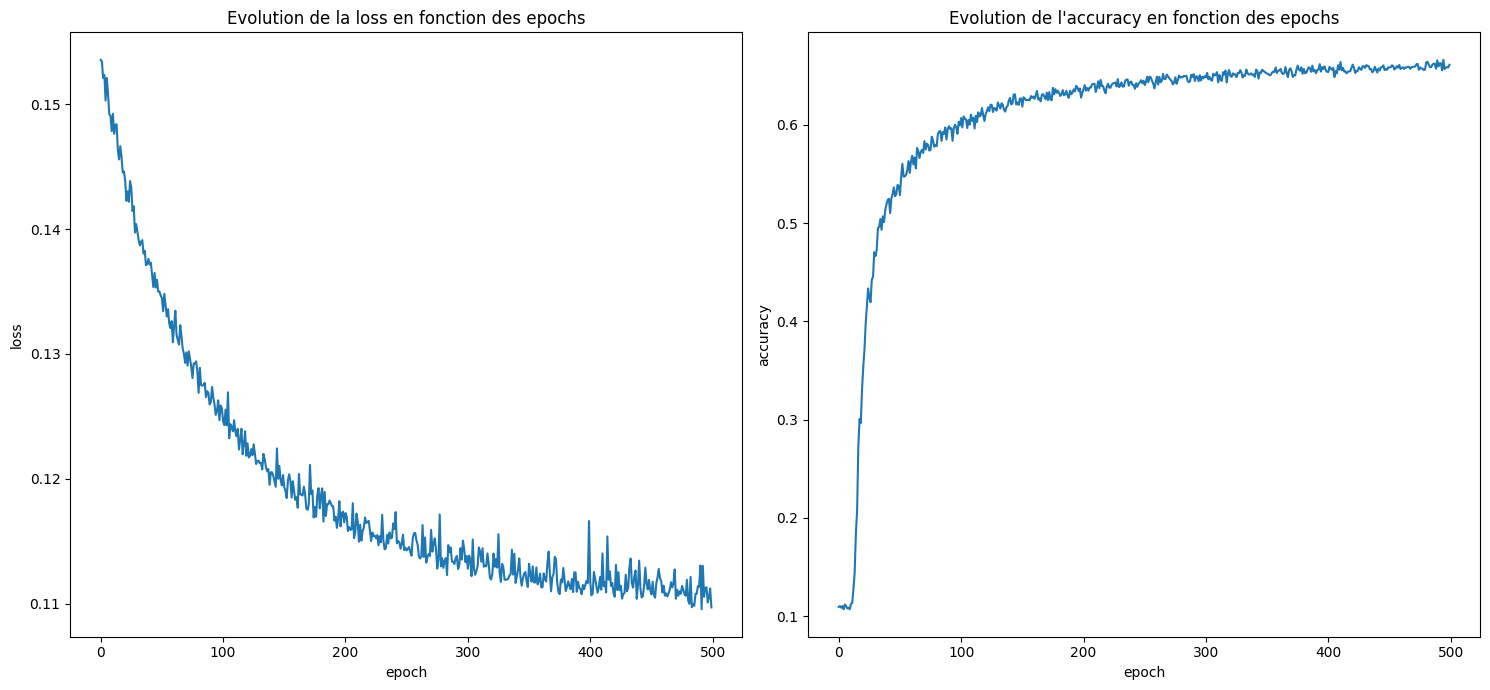

In [29]:
lr=0.2
nb_epochs = 500
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

In [ ]:
#torch.save(model.state_dict(), "model_near.pth")

In [44]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[-0.5122, -1.2046, -1.0388, -1.3037]])
bias
tensor([3.3480])


## 2 couches

In [11]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes

cpu


/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/torch/nn/functional.py:1944: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


accuracy train:  0.724860429763794


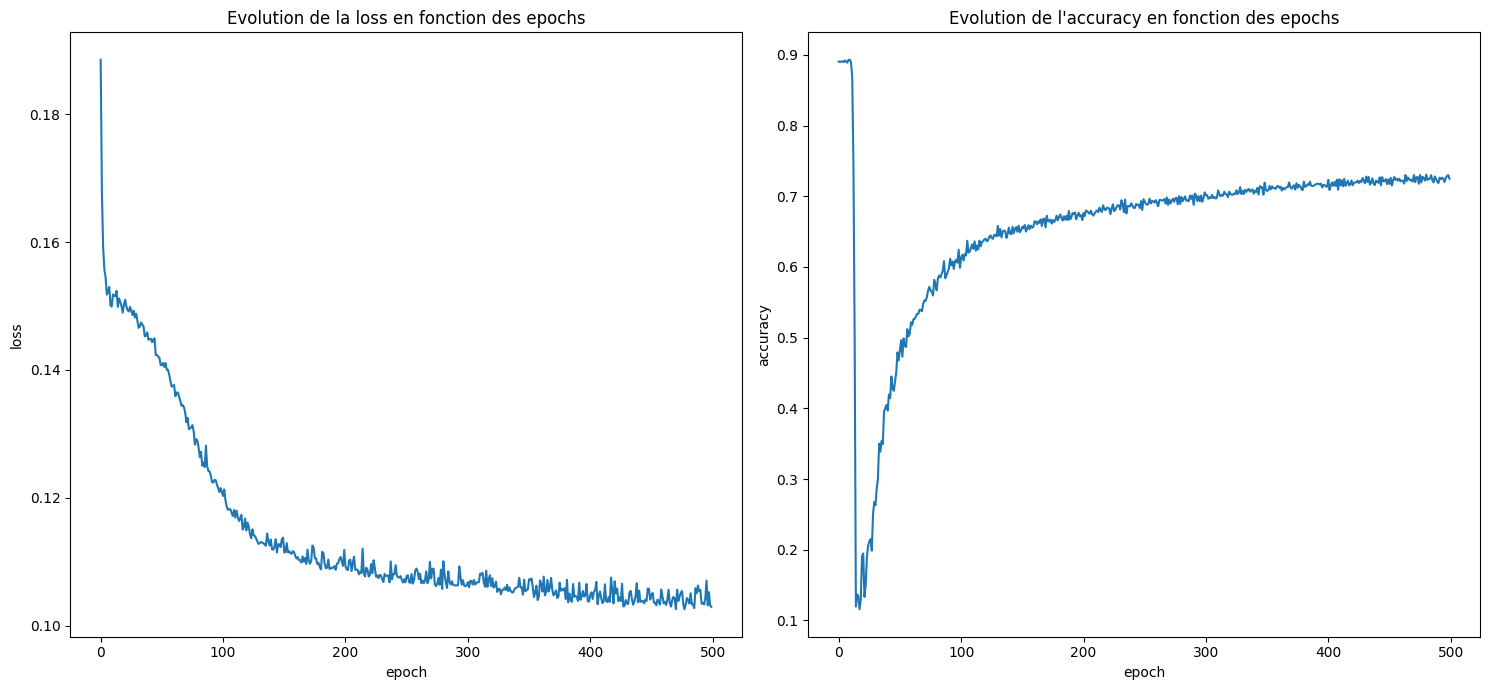

In [12]:
lr=0.1
nb_epochs = 500
optim = torch.optim.SGD(model.parameters(), lr)
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

cpu
accuracy train:  0.7578295204374526


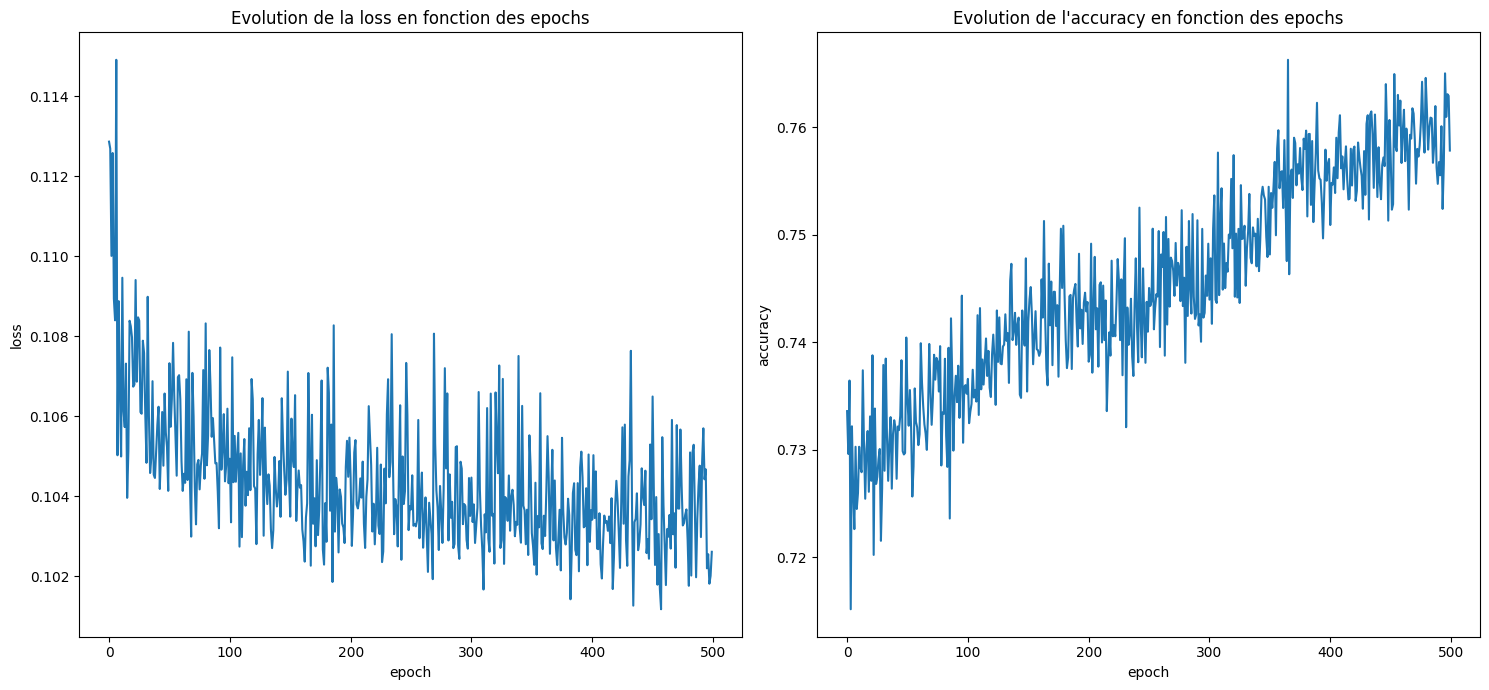

In [13]:
lr=1
nb_epochs = 500
optim = torch.optim.SGD(model.parameters(), lr)
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

cpu
accuracy train:  0.7708673742082384


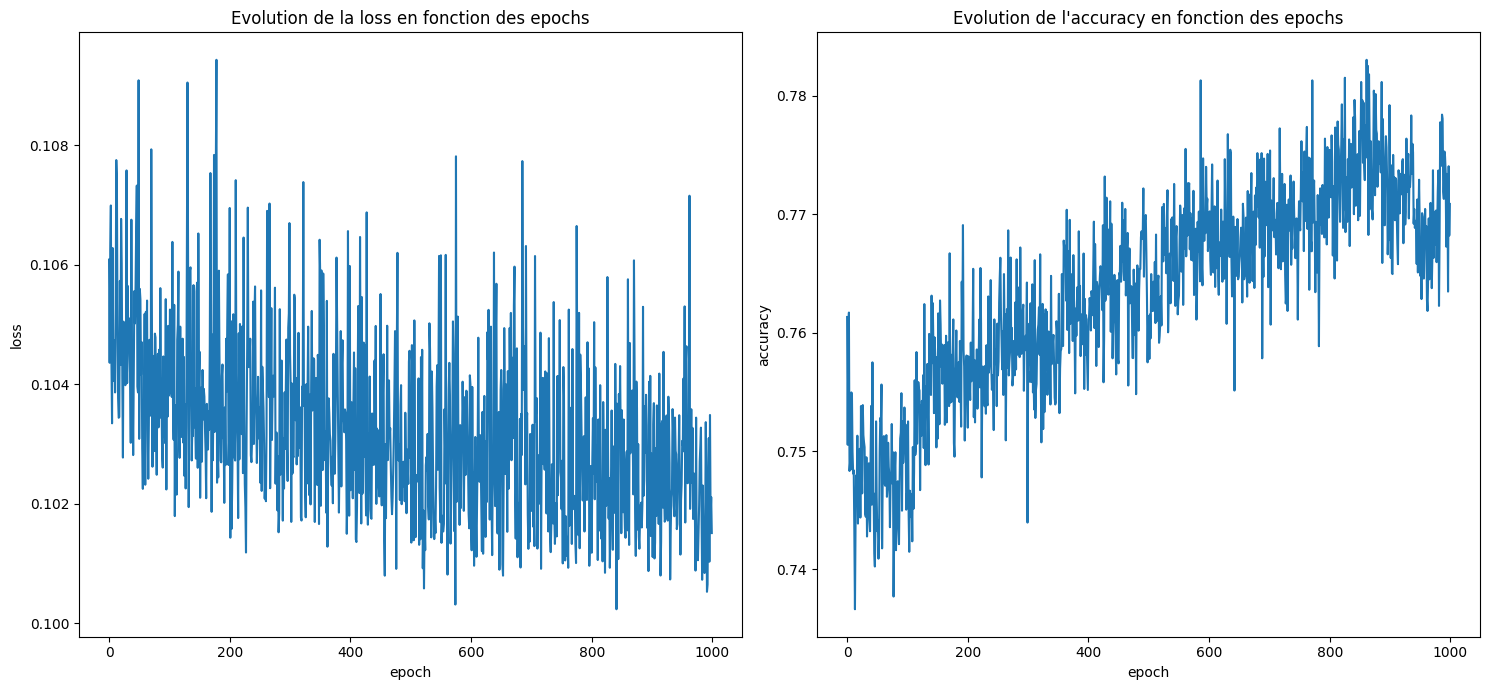

In [14]:
lr=2
nb_epochs = 1000
optim = torch.optim.SGD(model.parameters(), lr)
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

# Dataset UCF

## Chargement des données

In [5]:
data = data_all["UCF"]

In [6]:
X_tensor_train = torch.tensor(data['X_train'], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 

6116 elements (array([0., 1.], dtype=float32), array([ 824, 5292]))


In [7]:
X_tensor_test = torch.tensor(data['X_test'], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
y_tensor_test = 1-y_tensor_test# pour classification binaire
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

1530 elements (array([0., 1.], dtype=float32), array([1324,  206]))


## Modèle

In [9]:
# Calcul des poids des classes
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.15570672713529857

In [ ]:
input_dim = 4  #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Linear(input_dim, output_dim)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=0.2 
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 500

## Entrainement

accuracy train:  0.6717558547302529


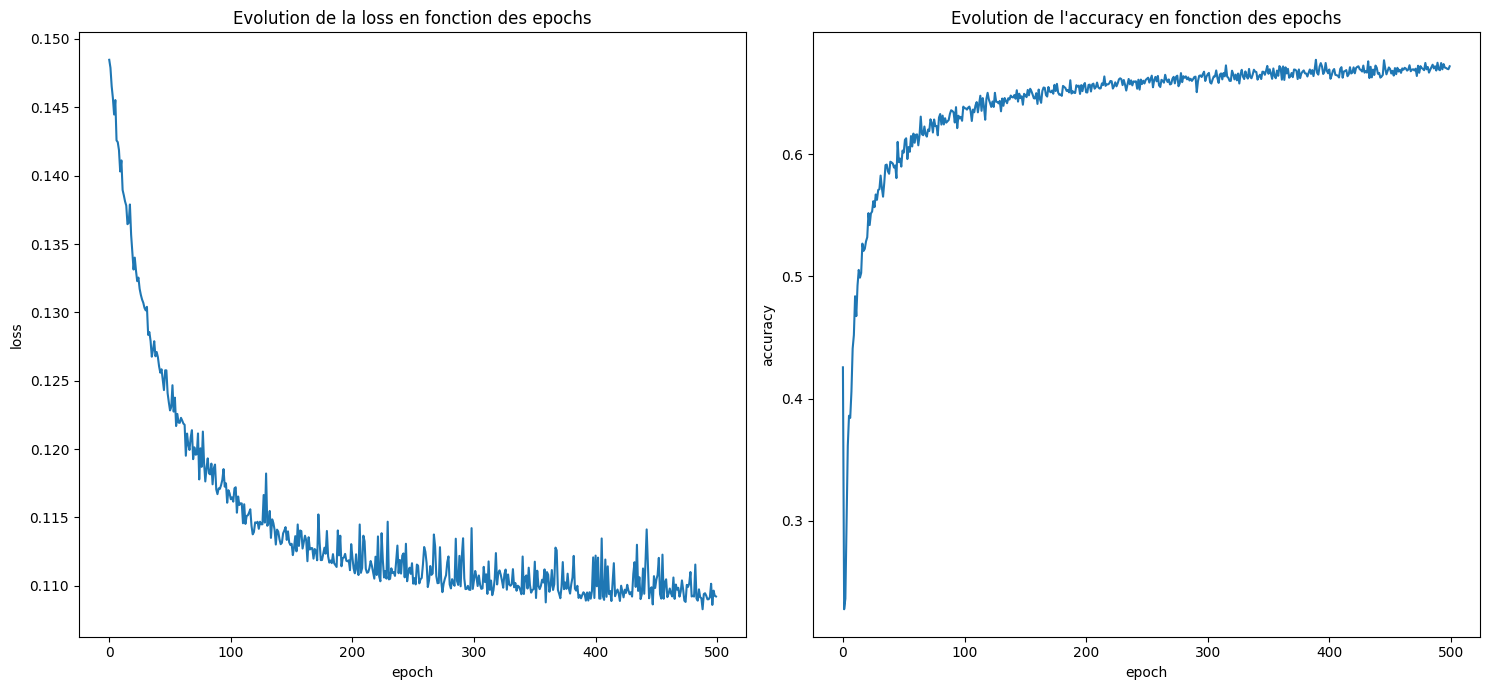

In [49]:
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].plot(np.arange(len(plot_loss)), plot_loss)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_title("Evolution de la loss en fonction des epochs")

ax[1].plot(np.arange(len(plot_acc)), plot_acc)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].set_title("Evolution de l'accuracy en fonction des epochs")

plt.tight_layout()
plt.show()
#lr 0.2

In [ ]:
#torch.save(model.state_dict(), "model.pth")

In [50]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[-1.3961, -2.3127, -2.1246, -1.4093]])
bias
tensor([6.2784])


## 2 couches

In [15]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes

cpu
accuracy train:  0.6546744791169962


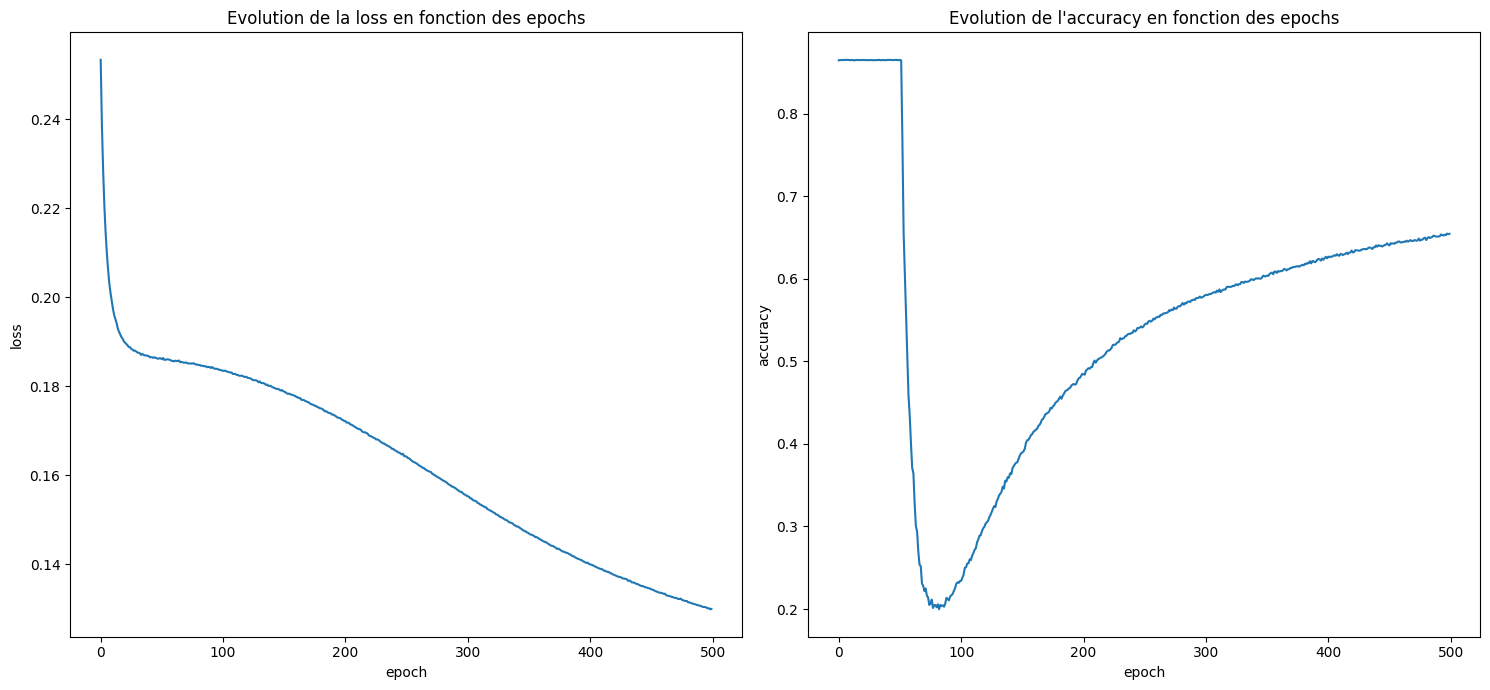

In [16]:
lr=0.01
nb_epochs = 500
optim = torch.optim.SGD(model.parameters(), lr)
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

cpu
accuracy train:  0.8124479167163372


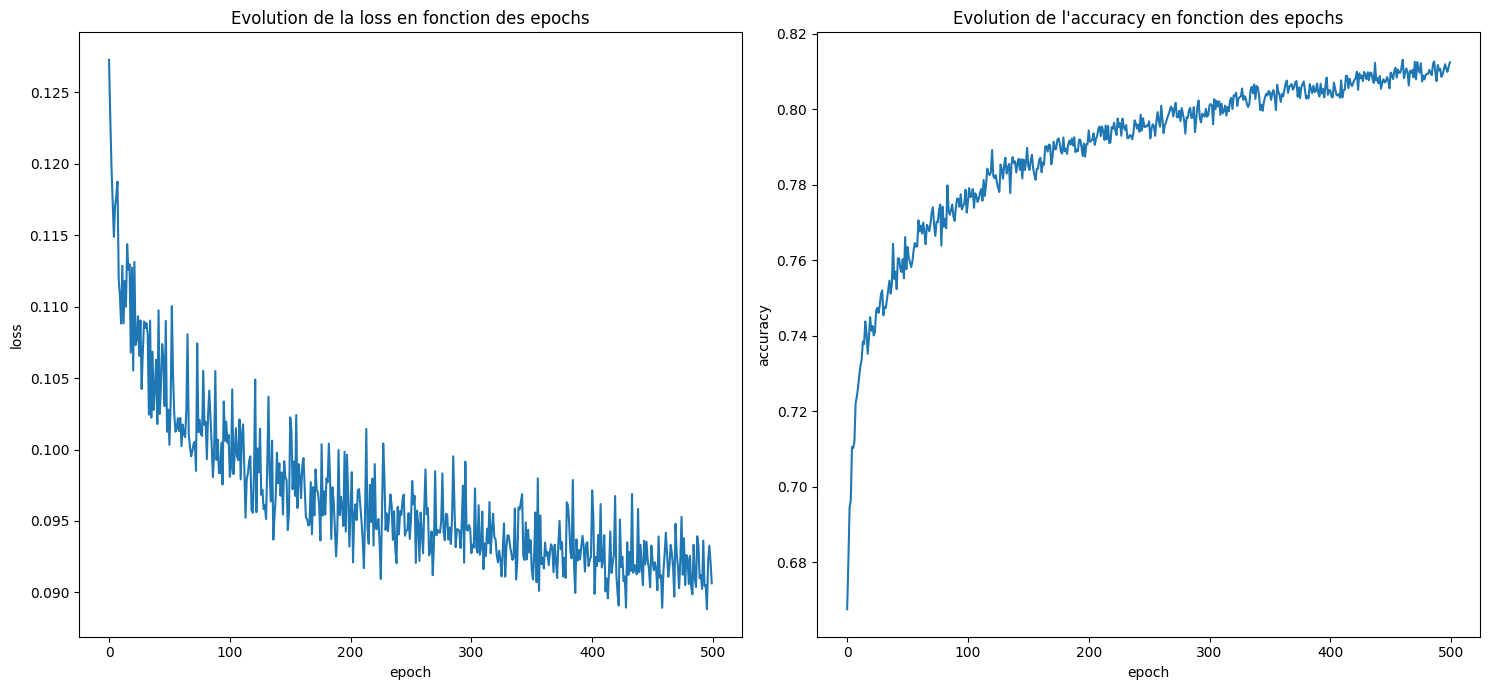

In [17]:
lr=1
nb_epochs = 500
optim = torch.optim.SGD(model.parameters(), lr)
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

cpu
accuracy train:  0.8402604162693024


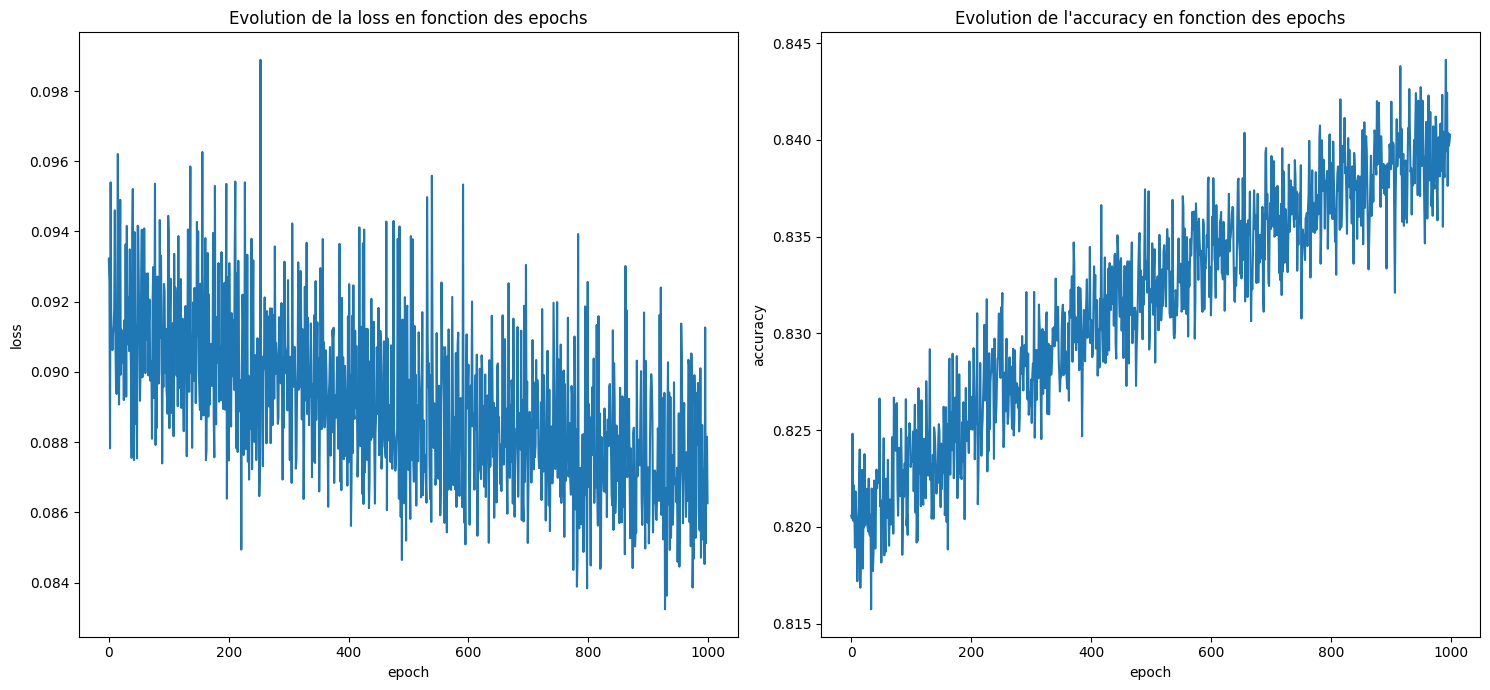

In [19]:
lr=2
nb_epochs = 1000
optim = torch.optim.SGD(model.parameters(), lr)
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

# Dataset EPIC

## Chargement des données

In [93]:
data = data_all["EPIC"]

In [94]:
X_tensor_train = torch.tensor(data['X_train'], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 

1484 elements (array([0., 1.], dtype=float32), array([ 429, 1055]))


In [95]:
X_tensor_test = torch.tensor(data['X_test'], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
y_tensor_test = 1-y_tensor_test# pour classification binaire
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

372 elements (array([0., 1.], dtype=float32), array([265, 107]))


## Modèle

In [54]:
# Calcul des poids des classes
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
#ratio = counts/np.sum(counts)
pos_weight = counts[0] / counts[1] # N_negative / N_positive
pos_weight

0.4066350710900474

In [77]:
input_dim = 4  #react sur tous + react sur aucun + react video + react flow + react audio
output_dim = 1
model = nn.Linear(input_dim, output_dim)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=0.2
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 500

## Entrainement

In [80]:
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)

accuracy train:  0.5563322355349859


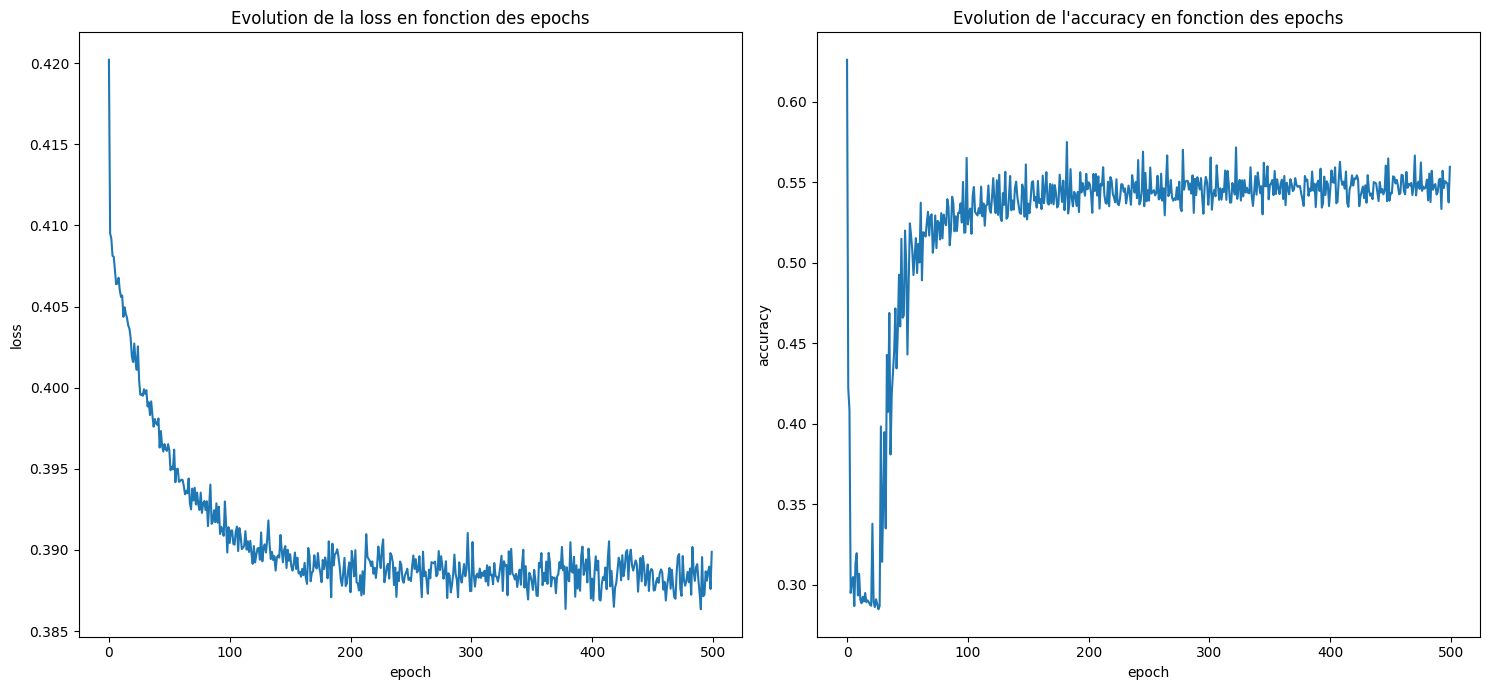

In [66]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].plot(np.arange(len(plot_loss)), plot_loss)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_title("Evolution de la loss en fonction des epochs")

ax[1].plot(np.arange(len(plot_acc)), plot_acc)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].set_title("Evolution de l'accuracy en fonction des epochs")

plt.tight_layout()
plt.show()


In [ ]:
torch.save(model.state_dict(), "model.pth")

In [68]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[ 0.3905,  0.4646, -0.3324, -0.2068]])
bias
tensor([0.4208])


## 2 couches

In [ ]:
input_dim = 4 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes

cpu
accuracy train:  0.6546744791169962


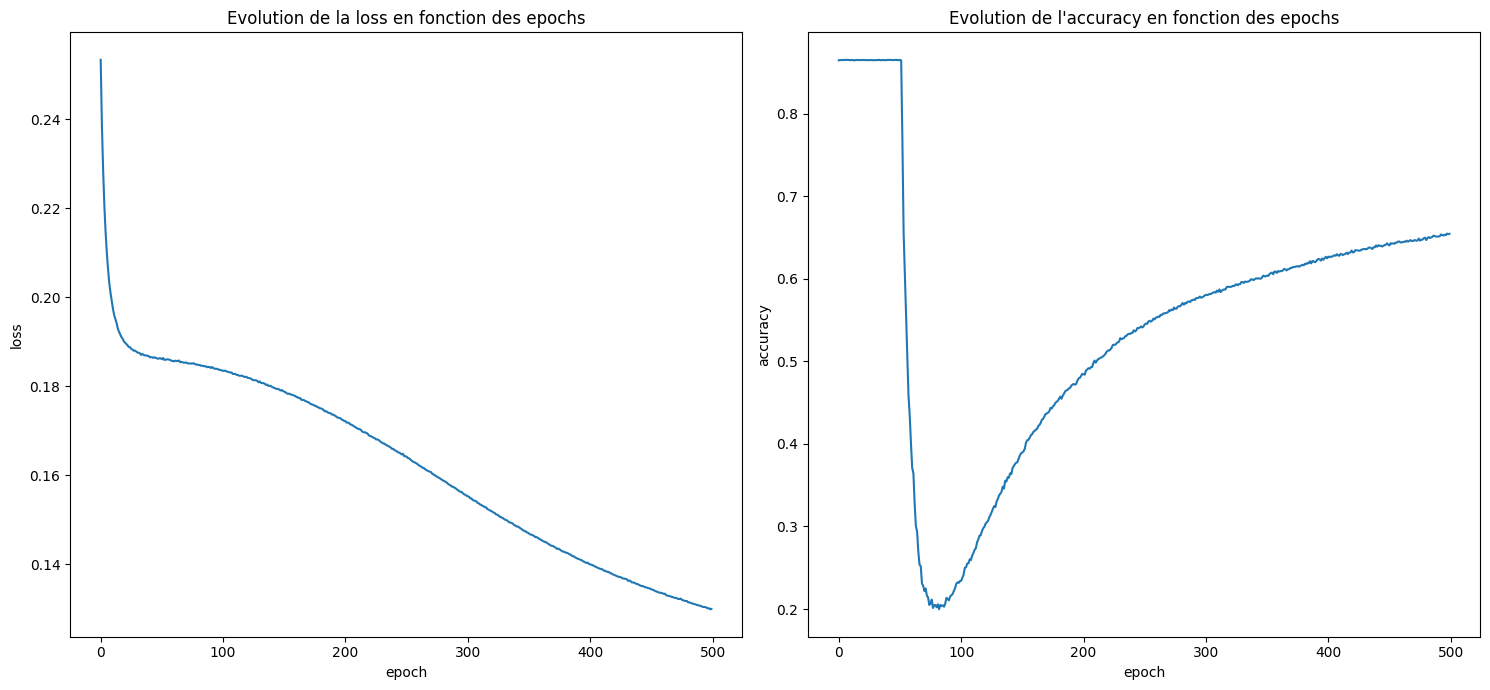

In [ ]:
lr=0.01
nb_epochs = 500
optim = torch.optim.SGD(model.parameters(), lr)
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)
visualize(plot_loss, plot_acc)

# Tests

### Séparabilité

In [ ]:
outputs_test = calc_outputs_test(model, test_dataloader)

# with open("outputs_test.pkl", 'wb') as f:
#     pickle.dump(outputs_test, f)

In [ ]:
with open("outputs_test.pkl", 'rb') as f:
    outputs_test = pickle.load(f)

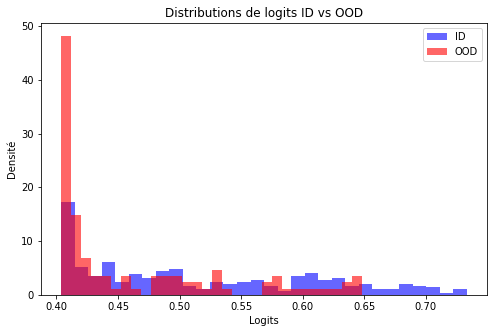

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(outputs_test["logits_id_test"], bins=30, alpha=0.6, label="ID", color='blue', density=True)
plt.hist(outputs_test["logits_ood_test"], bins=30, alpha=0.6, label="OOD", color='red', density=True)

plt.xlabel("Logits")
plt.ylabel("Densité")
plt.title("Distributions de logits ID vs OOD")
plt.legend()
plt.show()


### AUC & FPR

In [ ]:
auroc, aupr_in, aupr_out, fpr = auc_and_fpr_recall(np.array(outputs_test["all_outputs_test"]), np.array(outputs_test["all_labels_test"]), tpr_th=0.95)
auroc, fpr

(0.30072297654734614, 0.9962264150943396)

In [ ]:
X_tensor_train = torch.tensor(data['X_train'][:,:-1], dtype=torch.float32)
y_tensor_train = torch.tensor(data['y_train'], dtype=torch.float32)
train_dataset = TensorDataset(X_tensor_train, y_tensor_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_train), "elements", np.unique(y_tensor_train, return_counts=True)) 
X_tensor_train.shape

1484 elements (array([0., 1.], dtype=float32), array([ 429, 1055]))


torch.Size([1484, 4])

In [14]:
X_tensor_test = torch.tensor(data['X_test'][:,:-1], dtype=torch.float32)
y_tensor_test = torch.tensor(data['y_test'], dtype=torch.float32)
y_tensor_test = 1-y_tensor_test# pour classification binaire
test_dataset = TensorDataset(X_tensor_test, y_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)
print(len(X_tensor_test), "elements", np.unique(y_tensor_test, return_counts=True))

372 elements (array([0., 1.], dtype=float32), array([265, 107]))


In [ ]:
unique_values, counts = np.unique(y_tensor_train, return_counts=True) ### Entrainement avec pondération
pos_weight = counts[0] / counts[1] # N_negative / N_positive
input_dim = 4 #react sur tous + react sur aucun + react video + react flow
output_dim = 1
model = nn.Linear(input_dim, output_dim)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=0.1
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 50

0.4066350710900474

In [ ]:
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)

/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/torch/nn/functional.py:1944: UserWarning: nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.
  warnings.warn("nn.functional.sigmoid is deprecated. Use torch.sigmoid instead.")


accuracy train:  0.5075975176755418


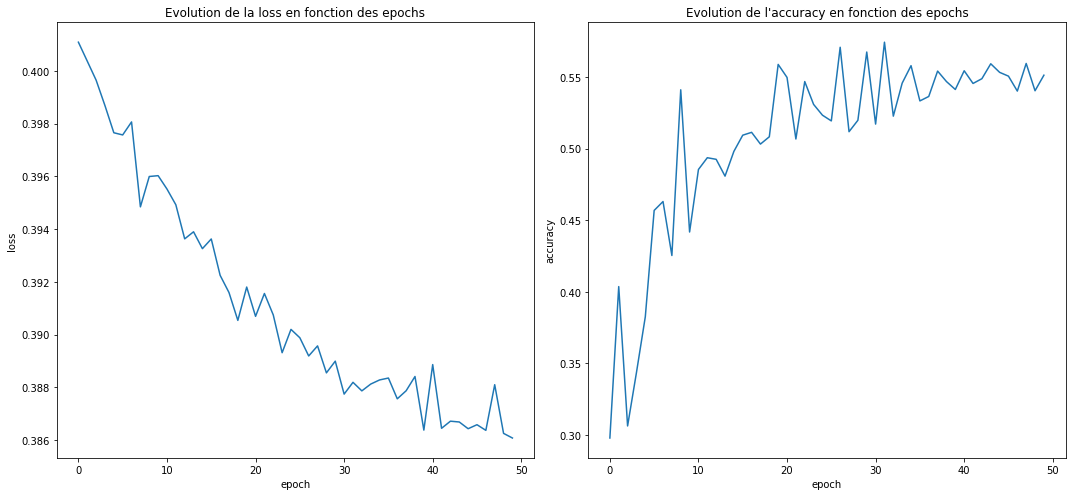

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].plot(np.arange(len(plot_loss)), plot_loss)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_title("Evolution de la loss en fonction des epochs")

ax[1].plot(np.arange(len(plot_acc)), plot_acc)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].set_title("Evolution de l'accuracy en fonction des epochs")

plt.tight_layout()
plt.show()


In [20]:
for name, param in model.named_parameters():
    print(f"{name}")
    print(param.data)

weight
tensor([[-0.5206,  0.1675, -0.7920, -0.6616]])
bias
tensor([1.4655])


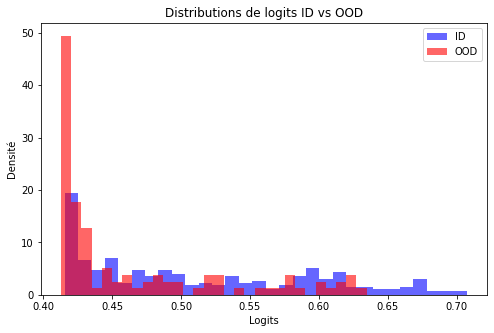

In [ ]:
outputs_test = calc_outputs_test(model, test_dataloader)
plt.figure(figsize=(8, 5))

plt.hist(outputs_test["logits_id_test"], bins=30, alpha=0.6, label="ID", color='blue', density=True)
plt.hist(outputs_test["logits_ood_test"], bins=30, alpha=0.6, label="OOD", color='red', density=True)

plt.xlabel("Logits")
plt.ylabel("Densité")
plt.title("Distributions de logits ID vs OOD")
plt.legend()
plt.show()


In [26]:
auroc, aupr_in, aupr_out, fpr = auc_and_fpr_recall(np.array(outputs_test["all_outputs_test"]), np.array(outputs_test["all_labels_test"]), tpr_th=0.95)
auroc, fpr

(0.29204725797919234, 1.0)

# Modèle 2 Couches

In [18]:
input_dim = 5 #react sur tous + react sur aucun + react video + react flow + react audio
hidden_dim = 2
output_dim = 1
model = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, output_dim))

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
lr=0.1
optim = torch.optim.SGD(model.parameters(), lr)
nb_epochs = 100

In [ ]:
# input_dim = 5 #react sur tous + react sur aucun + react video + react flow + react audio
# output_dim = 1
# model = nn.Linear(input_dim, output_dim)

# criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight)) # Pondération des classes
# lr=0.1
# optim = torch.optim.SGD(model.parameters(), lr)
# nb_epochs = 50

In [21]:
plot_loss, plot_acc, accuracy_train = train(model, train_dataloader, criterion, optim, nb_epochs)

accuracy train:  0.5732188870261113


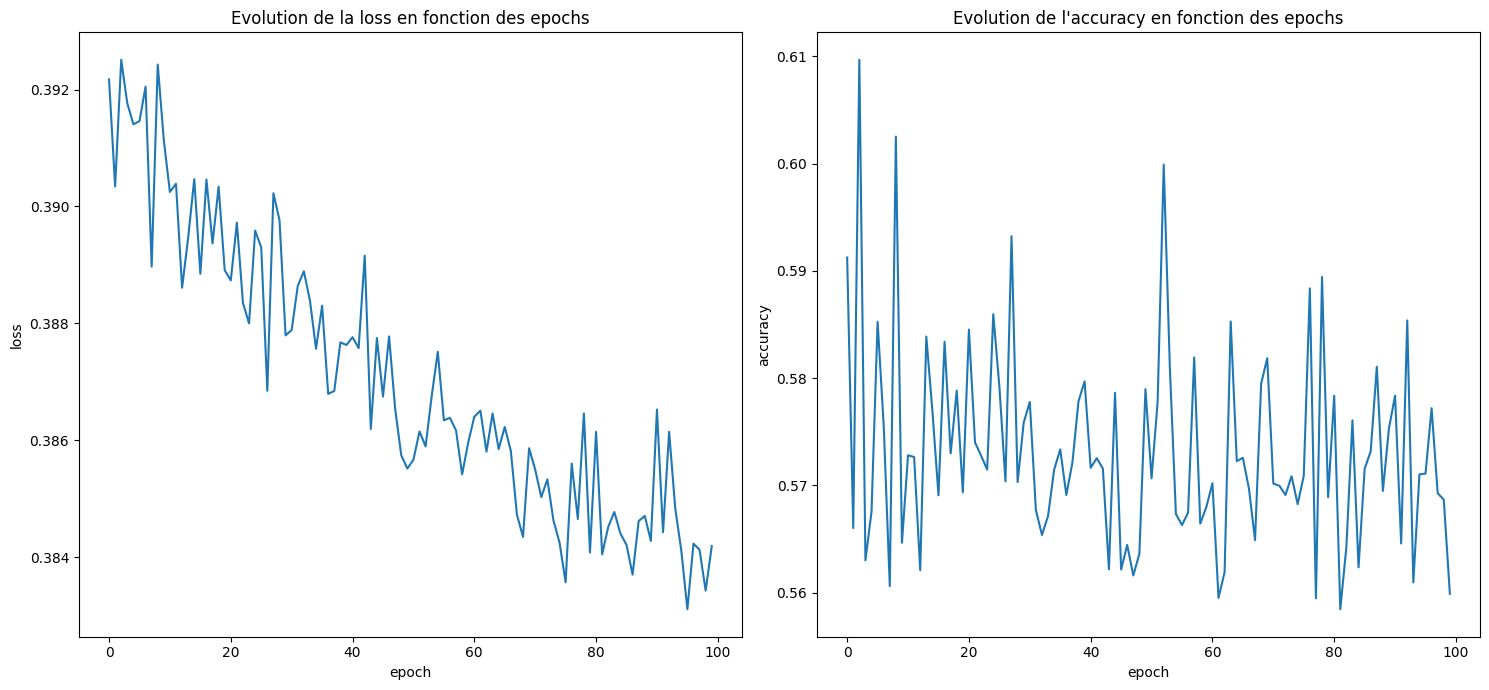

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].plot(np.arange(len(plot_loss)), plot_loss)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_title("Evolution de la loss en fonction des epochs")

ax[1].plot(np.arange(len(plot_acc)), plot_acc)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].set_title("Evolution de l'accuracy en fonction des epochs")

plt.tight_layout()
plt.show()


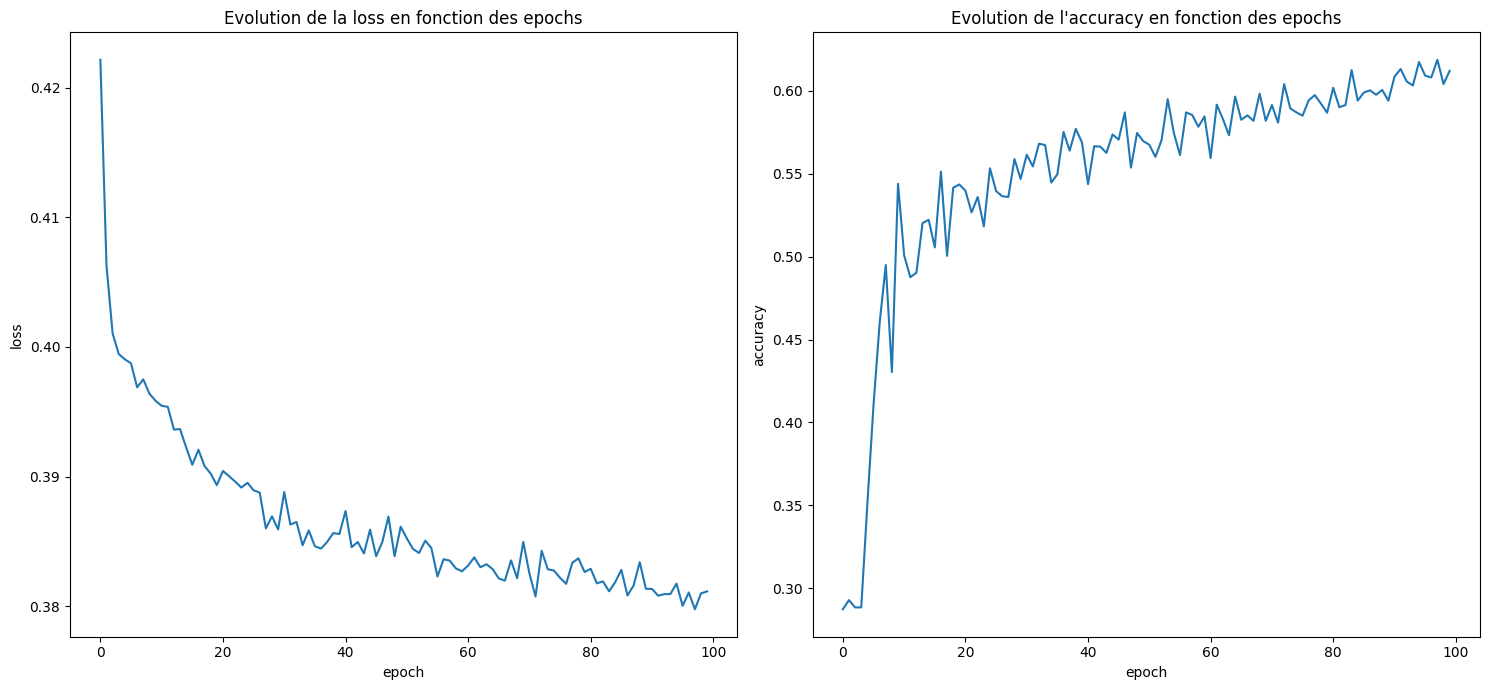

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

ax[0].plot(np.arange(len(plot_loss)), plot_loss)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_title("Evolution de la loss en fonction des epochs")

ax[1].plot(np.arange(len(plot_acc)), plot_acc)
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].set_title("Evolution de l'accuracy en fonction des epochs")

plt.tight_layout()
plt.show()


In [12]:
torch.save(model.state_dict(), "model_near_2c.pth")